# 05 - Analyser le découplage entre activité économique et empreinte climatique

Ce notebook utilise le cache préparé dans `05a` pour étudier l’évolution conjointe du PIB réel et des émissions de gaz à effet de serre. Il ne recharge aucune grande matrice EXIOBASE.

À la fin, vous saurez :

- distinguer découplage absolu, découplage relatif et couplage ;
- choisir un indicateur économique adapté à une comparaison temporelle ;
- lire une trajectoire PIB-empreinte ;
- comparer les comptes de production et de consommation ;
- tester la sensibilité du diagnostic à la période choisie.

## 1. Définir le découplage

Entre une année initiale et une année finale :

- il y a **découplage absolu** si le PIB réel augmente tandis que les émissions diminuent ;
- il y a **découplage relatif** si le PIB et les émissions augmentent, mais que les émissions progressent moins vite ;
- il y a **couplage** si les émissions augmentent au moins aussi vite que le PIB ;
- si le PIB diminue, cette classification ne suffit plus et le résultat est indiqué comme une contraction.

Le découplage décrit une évolution comptable. Il ne démontre pas à lui seul une relation causale entre croissance et émissions.

## 2. Réunir les données environnementales et économiques

Le cache EXIOBASE contient les émissions et la population. Le PIB d’EXIOBASE est en prix courants : sa hausse combine croissance réelle et inflation. Nous utilisons donc le PIB en dollars constants de 2015 publié par la Banque mondiale.

Source : [Banque mondiale, PIB en dollars constants de 2015](https://data.worldbank.org/indicator/NY.GDP.MKTP.KD).

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

DOSSIER_EXIOBASE = Path("D:/EXIOBASE/3.10.2")
DOSSIER_SERIE = DOSSIER_EXIOBASE / "serie_temporelle"
FICHIER_CLIMAT = DOSSIER_SERIE / "comptes_climat_regionaux.csv"
FICHIER_PIB_REEL = DOSSIER_SERIE / "pib_reel_banque_mondiale.csv"
DOSSIER_FIGURES = Path("figures")
DOSSIER_FIGURES.mkdir(exist_ok=True)

if not FICHIER_CLIMAT.exists():
    raise FileNotFoundError(
        "Cache climatique absent. Exécutez d’abord 05a_precalculer_serie_temporelle.ipynb."
    )

In [3]:
climat = pd.read_csv(FICHIER_CLIMAT)
annees_disponibles = sorted(climat["annee"].unique())
annees_attendues = list(range(1995, 2023))
annees_manquantes = sorted(set(annees_attendues) - set(annees_disponibles))

if annees_manquantes:
    raise RuntimeError(
        f"Série EXIOBASE incomplète. Années manquantes : {annees_manquantes}. "
        "Reprenez le notebook 05a."
    )
print(f"Série climatique complète : {annees_disponibles[0]} à {annees_disponibles[-1]}.")

Série climatique complète : 1995 à 2022.


### Correspondance avec la Banque mondiale

L’API de la Banque mondiale identifie les pays par leur code ISO3. Les cinq régions agrégées d’EXIOBASE ne correspondent pas à des pays. Taïwan ne dispose pas non plus d’une série dans cette source. Ces six régions restent dans les totaux EXIOBASE, mais sont exclues des comparaisons nationales avec le PIB réel.

In [4]:
exio_vers_iso3 = {
    "AT": "AUT", "BE": "BEL", "BG": "BGR", "CY": "CYP",
    "CZ": "CZE", "DE": "DEU", "DK": "DNK", "EE": "EST",
    "ES": "ESP", "FI": "FIN", "FR": "FRA", "GR": "GRC",
    "HR": "HRV", "HU": "HUN", "IE": "IRL", "IT": "ITA",
    "LT": "LTU", "LU": "LUX", "LV": "LVA", "MT": "MLT",
    "NL": "NLD", "PL": "POL", "PT": "PRT", "RO": "ROU",
    "SE": "SWE", "SI": "SVN", "SK": "SVK", "GB": "GBR",
    "US": "USA", "JP": "JPN", "CN": "CHN", "CA": "CAN",
    "KR": "KOR", "BR": "BRA", "IN": "IND", "MX": "MEX",
    "RU": "RUS", "AU": "AUS", "CH": "CHE", "TR": "TUR",
    "NO": "NOR", "ID": "IDN", "ZA": "ZAF",
}
iso3_vers_exio = {iso3: exio for exio, iso3 in exio_vers_iso3.items()}

In [5]:
if not FICHIER_PIB_REEL.exists():
    codes = ";".join(sorted(iso3_vers_exio))
    url = (
        f"https://api.worldbank.org/v2/country/{codes}/indicator/"
        "NY.GDP.MKTP.KD?format=json&per_page=2000&date=1995:2022"
    )
    reponse = requests.get(url, timeout=120)
    reponse.raise_for_status()
    contenu = reponse.json()
    if not isinstance(contenu, list) or len(contenu) < 2:
        raise ValueError("Réponse inattendue de l’API de la Banque mondiale.")

    lignes = [
        {
            "annee": int(element["date"]),
            "iso3": element["countryiso3code"],
            "pib_reel_usd_2015": element["value"],
        }
        for element in contenu[1]
        if element["value"] is not None
    ]
    pib_reel = pd.DataFrame(lignes)
    temporaire = FICHIER_PIB_REEL.with_suffix(".csv.part")
    pib_reel.to_csv(temporaire, index=False)
    temporaire.replace(FICHIER_PIB_REEL)
else:
    pib_reel = pd.read_csv(FICHIER_PIB_REEL)

print(f"{len(pib_reel)} observations de PIB réel chargées.")

1204 observations de PIB réel chargées.


In [6]:
pib_reel["region"] = pib_reel["iso3"].map(iso3_vers_exio)
donnees = climat.merge(
    pib_reel[["annee", "region", "pib_reel_usd_2015"]],
    on=["annee", "region"], how="left", validate="one_to_one",
)
donnees["pib_reel_par_habitant"] = (
    donnees["pib_reel_usd_2015"] / donnees["population"]
)
donnees["empreinte_t_par_habitant"] = (
    donnees["ghg_cba_kgco2e"] / donnees["population"] / 1_000
)
donnees["production_t_par_habitant"] = (
    donnees["ghg_pba_observe_kgco2e"] / donnees["population"] / 1_000
)
donnees["intensite_kg_par_usd_2015"] = (
    donnees["ghg_cba_kgco2e"] / donnees["pib_reel_usd_2015"]
)
donnees = donnees.set_index(["annee", "region"]).sort_index()

In [7]:
couverture_pib = donnees["pib_reel_usd_2015"].notna().groupby(level="region").sum()
regions_completes = couverture_pib[couverture_pib.eq(len(annees_attendues))].index
regions_incompletes = couverture_pib[couverture_pib.lt(len(annees_attendues))]

pd.Series(
    {
        "régions avec 28 années de PIB": len(regions_completes),
        "régions incomplètes ou sans PIB": len(regions_incompletes),
    },
    name="couverture",
).to_frame()

,couverture
régions avec 28 années de PIB,43
régions incomplètes ou sans PIB,6


In [8]:
pd.Series({
    "années disponibles": donnees.index.get_level_values("annee").nunique(),
    "régions EXIOBASE": donnees.index.get_level_values("region").nunique(),
}, name="couverture des données")

années disponibles    28
régions EXIOBASE      49
Name: couverture des données, dtype: int64

In [9]:
# Composition de l’UE27 depuis le retrait du Royaume-Uni.
REGIONS_UE27 = [
    "AT", "BE", "BG", "CY", "CZ", "DE", "DK", "EE", "ES",
    "FI", "FR", "GR", "HR", "HU", "IE", "IT", "LT", "LU",
    "LV", "MT", "NL", "PL", "PT", "RO", "SE", "SI", "SK",
]
assert len(REGIONS_UE27) == 27

In [10]:
# Vérifier que chaque membre est présent et possède toute la série de PIB.
assert set(REGIONS_UE27) <= set(exio_vers_iso3)
assert set(REGIONS_UE27) <= set(regions_completes)
pd.Series(exio_vers_iso3).loc[REGIONS_UE27].rename("code ISO3").to_frame().T

,AT,BE,BG,CY,CZ,DE,DK,EE,ES,FI,...,LU,LV,MT,NL,PL,PT,RO,SE,SI,SK
code ISO3,AUT,BEL,BGR,CYP,CZE,DEU,DNK,EST,ESP,FIN,...,LUX,LVA,MLT,NLD,POL,PRT,ROU,SWE,SVN,SVK


In [11]:
# Ces grandeurs sont additives entre pays. Les ratios seront recalculés après la somme.
COLONNES_ADDITIVES = [
    "ghg_cba_kgco2e",
    "ghg_pba_observe_kgco2e",
    "ghg_pba_attribuable_kgco2e",
    "ghg_final_direct_kgco2e",
    "pib_exiobase_meur_courants",
    "population",
    "pib_reel_usd_2015",
]

In [12]:
idx = pd.IndexSlice
donnees_ue27 = (
    donnees.loc[idx[:, REGIONS_UE27], COLONNES_ADDITIVES]
    .groupby(level="annee")
    .sum(min_count=len(REGIONS_UE27))
)

In [13]:
# Un ratio européen est un ratio de totaux, pas une somme de ratios nationaux.
donnees_ue27["pib_reel_par_habitant"] = (
    donnees_ue27["pib_reel_usd_2015"] / donnees_ue27["population"]
)
donnees_ue27["empreinte_t_par_habitant"] = (
    donnees_ue27["ghg_cba_kgco2e"] / donnees_ue27["population"] / 1_000
)
donnees_ue27["production_t_par_habitant"] = (
    donnees_ue27["ghg_pba_observe_kgco2e"] / donnees_ue27["population"] / 1_000
)
donnees_ue27["intensite_kg_par_usd_2015"] = (
    donnees_ue27["ghg_cba_kgco2e"] / donnees_ue27["pib_reel_usd_2015"]
)
donnees_ue27["region"] = "UE27"
donnees_ue27 = donnees_ue27.set_index("region", append=True)
donnees = pd.concat([donnees, donnees_ue27]).sort_index()

In [14]:
controle_ue27 = donnees.xs("UE27", level="region")[[
    "population", "pib_reel_usd_2015",
    "empreinte_t_par_habitant", "production_t_par_habitant",
]]
assert len(controle_ue27) == len(annees_attendues)
assert controle_ue27.notna().all().all()
controle_ue27.loc[[annees_attendues[0], annees_attendues[-1]]].round(2)

,population,pib_reel_usd_2015,empreinte_t_par_habitant,production_t_par_habitant
annee,,,,
1995,424864000,9.811294e+12,11.76,10.36
2022,445182000,1.547598e+13,9.95,7.69


## 3. Reproduire la trajectoire `GHG_GDP.svg`

Chaque courbe relie les observations annuelles d’un pays. Aller vers la droite signifie que le PIB réel par habitant augmente. Descendre signifie que l’empreinte climatique par habitant diminue.

Les segments récents sont plus foncés. Les points initial et final sont marqués, mais aucune interpolation n’est ajoutée entre les observations.

In [15]:
def tracer_trajectoires(regions, donnees_source=donnees):
    fig, ax = plt.subplots(figsize=(13, 9))
    couleurs = plt.get_cmap("tab20").colors

    for numero, region in enumerate(regions):
        serie = donnees_source.xs(region, level="region").dropna(
            subset=["pib_reel_par_habitant", "empreinte_t_par_habitant"]
        )
        x = serie["pib_reel_par_habitant"]
        y = serie["empreinte_t_par_habitant"]
        est_ue27 = region == "UE27"
        couleur = "black" if est_ue27 else couleurs[numero % len(couleurs)]
        largeur = 3 if est_ue27 else 2

        for position in range(len(serie) - 1):
            alpha = 0.15 + 0.85 * position / max(len(serie) - 2, 1)
            ax.plot(
                x.iloc[position:position + 2],
                y.iloc[position:position + 2],
                color=couleur, alpha=alpha, linewidth=largeur,
            )

        ax.scatter(x.iloc[0], y.iloc[0], facecolors="white", edgecolors=[couleur])
        ax.scatter(x.iloc[-1], y.iloc[-1], color=couleur, zorder=3)
        ax.annotate(
            f"{region} {serie.index[-1]}",
            (x.iloc[-1], y.iloc[-1]), xytext=(5, 0),
            textcoords="offset points", va="center", color=couleur,
        )

    ax.set(
        xlabel="PIB réel par habitant, dollars constants de 2015",
        ylabel="empreinte climatique, t CO2e par habitant",
        title=(
            f"Trajectoires du PIB et de l’empreinte climatique, "
            f"{annees_disponibles[0]}-{annees_disponibles[-1]}"
        ),
    )
    ax.grid(alpha=0.25)
    return fig, ax

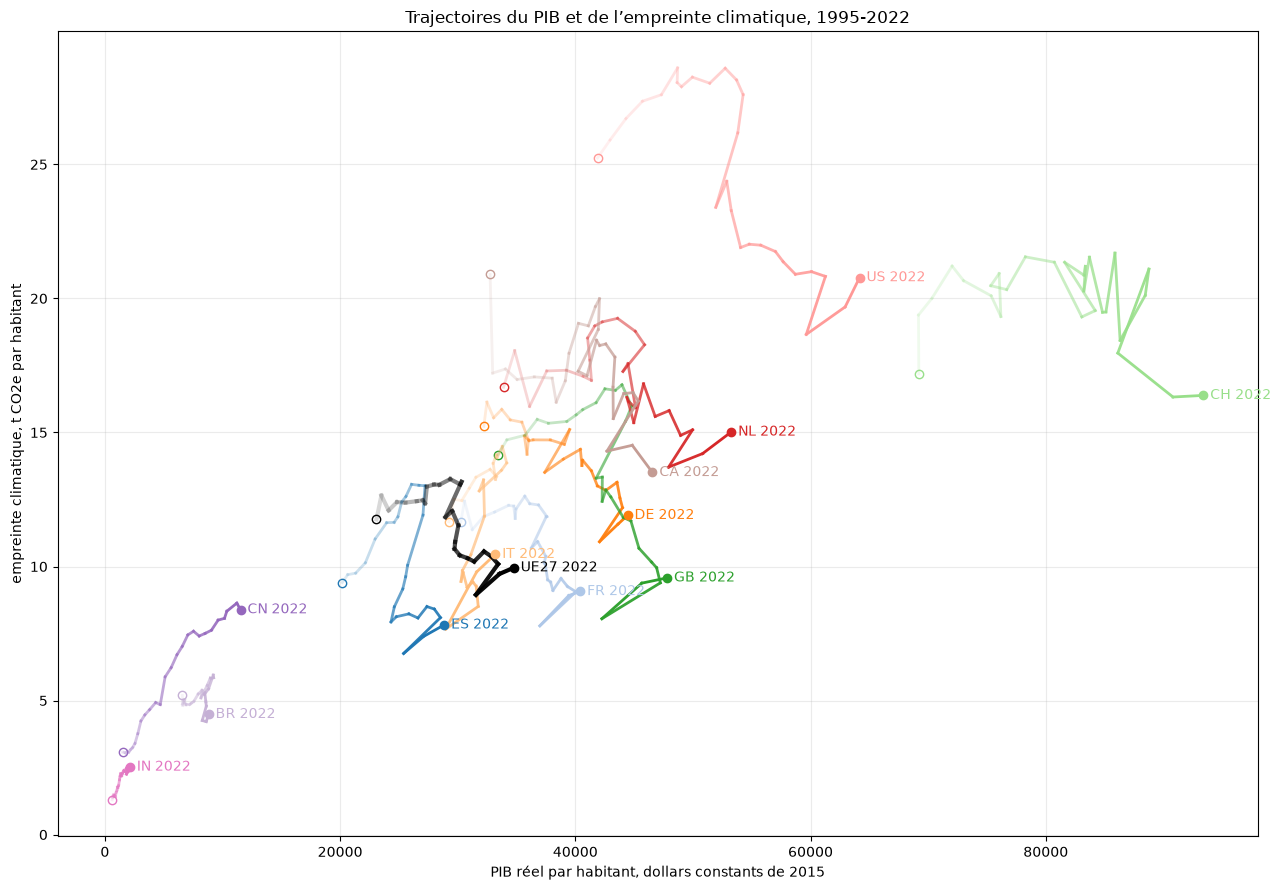

In [26]:
PAYS_FIGURE = ["ES", "FR", "DE", "IT", "GB", "CH", "NL", "US", "CN", "BR", "UE27", "CA", "IN"]
assert set(PAYS_FIGURE) <= set(donnees.index.get_level_values("region"))
assert donnees.loc[idx[:, PAYS_FIGURE], [
    "pib_reel_par_habitant", "empreinte_t_par_habitant",
]].notna().all().all()
fig, ax = tracer_trajectoires(PAYS_FIGURE)
fig.tight_layout()
fig.savefig(DOSSIER_FIGURES / "GHG_GDP.svg", bbox_inches="tight")

## 4. Comparer les évolutions sur une base commune

La trajectoire précédente montre des niveaux. Pour comparer des rythmes d’évolution, nous fixons la première année à l’indice 100. Une empreinte qui passe sous 100 a diminué en valeur absolue. Une intensité qui diminue indique seulement que l’empreinte croît moins vite que le PIB, ou qu’elle décroît.

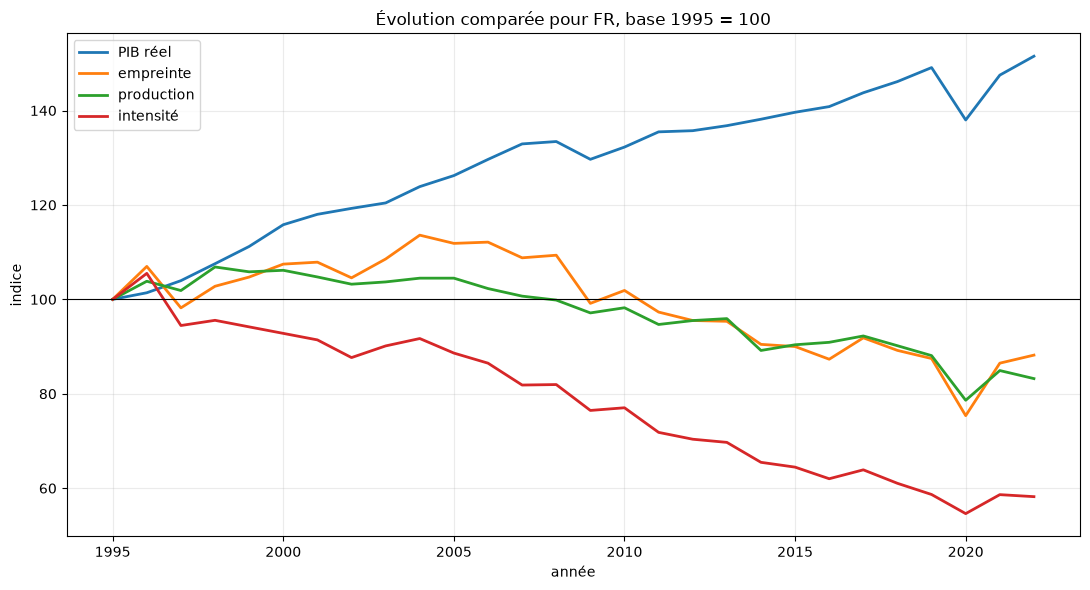

In [17]:
PAYS = "FR"
serie_pays = donnees.xs(PAYS, level="region")
indices = serie_pays[[
    "pib_reel_usd_2015",
    "ghg_cba_kgco2e",
    "ghg_pba_observe_kgco2e",
    "intensite_kg_par_usd_2015",
]].div(serie_pays.iloc[0][[
    "pib_reel_usd_2015",
    "ghg_cba_kgco2e",
    "ghg_pba_observe_kgco2e",
    "intensite_kg_par_usd_2015",
]]) * 100
indices.columns = ["PIB réel", "empreinte", "production", "intensité"]

ax = indices.plot(figsize=(11, 6), linewidth=2)
ax.axhline(100, color="black", linewidth=0.8)
ax.set(
    title=f"Évolution comparée pour {PAYS}, base {indices.index[0]} = 100",
    xlabel="année", ylabel="indice",
)
ax.grid(alpha=0.25)
plt.tight_layout()

## 5. Classer les évolutions

Le diagnostic suivant compare les variations relatives du PIB réel et de l’empreinte totale. Il utilise les niveaux nationaux, pas les valeurs par habitant. Le choix des deux années est déterminant : un résultat de long terme peut masquer des phases très différentes.

In [18]:
def diagnostiquer_decouplage(debut, fin, regions):
    lignes = []
    for region in regions:
        pays = donnees.xs(region, level="region")
        variation_pib = pays.loc[fin, "pib_reel_usd_2015"] / pays.loc[debut, "pib_reel_usd_2015"] - 1
        variation_ghg = pays.loc[fin, "ghg_cba_kgco2e"] / pays.loc[debut, "ghg_cba_kgco2e"] - 1

        if variation_pib <= 0:
            diagnostic = "contraction ou stagnation du PIB"
        elif variation_ghg < 0:
            diagnostic = "découplage absolu"
        elif variation_ghg < variation_pib:
            diagnostic = "découplage relatif"
        else:
            diagnostic = "couplage ou recouplage"

        lignes.append({
            "région": region,
            "variation du PIB réel (%)": 100 * variation_pib,
            "variation de l’empreinte (%)": 100 * variation_ghg,
            "diagnostic": diagnostic,
        })
    return pd.DataFrame(lignes).set_index("région")

In [19]:
diagnostic_long = diagnostiquer_decouplage(1995, 2022, PAYS_FIGURE)
diagnostic_long.round(1)

,variation du PIB réel (%),variation de l’empreinte (%),diagnostic
région,,,
ES,67.8,-2.3,découplage absolu
FR,51.5,-11.8,découplage absolu
DE,42.6,-19.2,découplage absolu
BE,62.8,15.7,découplage relatif
IT,19.6,-5.6,découplage absolu
GB,69.2,-20.1,découplage absolu
CH,69.2,19.6,découplage relatif
NL,74.8,0.1,découplage relatif
US,93.4,3.9,découplage relatif


## 6. Tester la sensibilité à la période

Nous comparons le diagnostic de long terme à celui de la période 2010-2022. Un changement de catégorie indique que le mot découplage doit toujours être accompagné d’un périmètre temporel.

In [20]:
diagnostic_recent = diagnostiquer_decouplage(2010, 2022, PAYS_FIGURE)
comparaison_diagnostics = pd.concat(
    {
        "1995-2022": diagnostic_long["diagnostic"],
        "2010-2022": diagnostic_recent["diagnostic"],
    },
    axis=1,
)
comparaison_diagnostics["diagnostic différent"] = (
    comparaison_diagnostics["1995-2022"]
    != comparaison_diagnostics["2010-2022"]
)
comparaison_diagnostics

,1995-2022,2010-2022,diagnostic différent
région,,,
ES,découplage absolu,découplage absolu,False
FR,découplage absolu,découplage absolu,False
DE,découplage absolu,découplage absolu,False
BE,découplage relatif,découplage absolu,True
IT,découplage absolu,découplage absolu,False
GB,découplage absolu,découplage absolu,False
CH,découplage relatif,découplage absolu,True
NL,découplage relatif,découplage absolu,True
US,découplage relatif,découplage absolu,True


## 7. Le résultat dépend aussi du principe comptable

Une baisse des émissions de production peut accompagner une hausse des émissions importées. Il faut donc comparer le compte de production et l’empreinte de consommation avant de conclure à un découplage environnemental national.

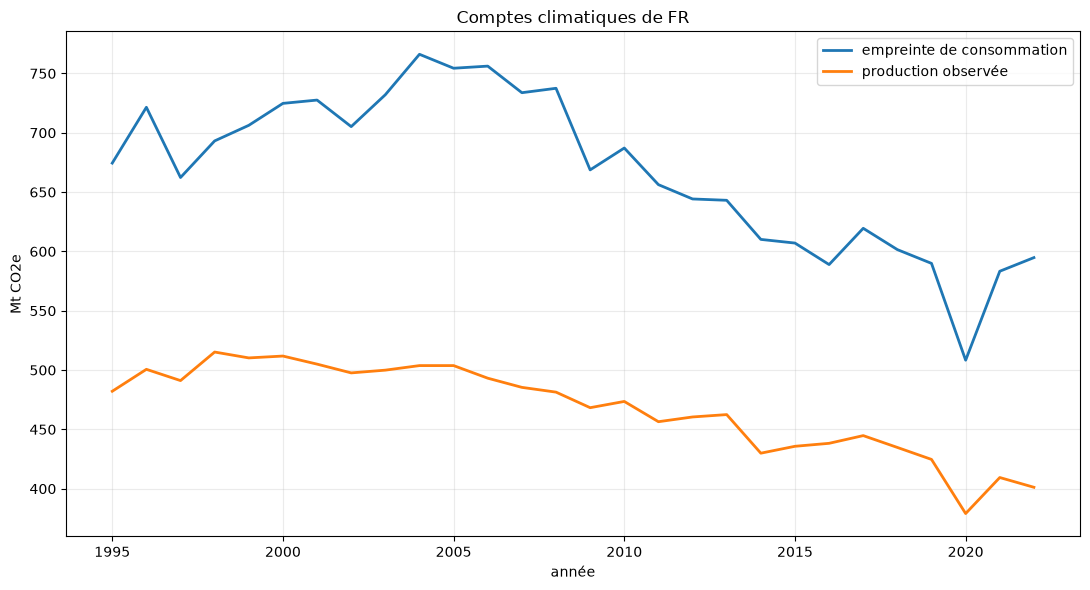

In [21]:
comparaison = serie_pays[["ghg_cba_kgco2e", "ghg_pba_observe_kgco2e"]] * 1e-9
comparaison.columns = ["empreinte de consommation", "production observée"]
ax = comparaison.plot(figsize=(11, 6), linewidth=2)
ax.set(
    title=f"Comptes climatiques de {PAYS}",
    xlabel="année", ylabel="Mt CO2e",
)
ax.grid(alpha=0.25)
plt.tight_layout()

## 8. Pourquoi ne pas ajuster simplement une régression ?

Le notebook historique testait plusieurs régressions entre PIB et émissions. Elles ne sont pas reprises ici, car deux séries temporelles tendancielles peuvent apparaître fortement liées sans relation causale. Les observations annuelles sont aussi autocorrélées et affectées par des ruptures comme les crises économiques ou sanitaires.

Une analyse économétrique serait possible, mais elle demanderait une question causale, un modèle temporel, des tests de stationnarité, des variables de contrôle et une analyse des ruptures. Pour un poster pédagogique, la trajectoire, les indices et la sensibilité aux dates sont plus transparents.

## 9. Limites à documenter

Avant de présenter les résultats, il faut préciser :

- la version d’EXIOBASE et le périmètre climatique ;
- le caractère réel du PIB et son année de prix de référence ;
- la différence entre comptes de production et de consommation ;
- le choix des années initiale et finale ;
- les changements éventuels de qualité statistique dans la série ;
- les effets des crises et autres ruptures ;
- l’absence de preuve causale dans un simple diagnostic de découplage.

## 10. Questions pour guider l’interprétation

1. Un pays peut-il présenter un découplage absolu pour sa production mais pas pour sa consommation ?
2. Le diagnostic change-t-il lorsque 2010 remplace 1995 comme année de départ ?
3. Que montre la trajectoire PIB-empreinte qu’un simple rapport entre deux dates masque ?
4. Faut-il privilégier les grandeurs totales ou par habitant pour parler de découplage national ?
5. Quels événements historiques devraient être signalés sur la figure ?

## À retenir

- le découplage absolu exige une baisse des pressions en valeur absolue pendant que le PIB réel augmente ;
- une baisse de l’intensité environnementale ne suffit pas à démontrer un découplage absolu ;
- le PIB nominal ne convient pas pour mesurer une croissance dans le temps ;
- le principe comptable et la période peuvent changer le diagnostic ;
- une trajectoire annuelle est plus informative qu’une comparaison de deux seuls points ;
- un diagnostic descriptif de découplage ne constitue pas une démonstration causale.